# Taller abandono de producto financiero

In [1]:
%pip install pandas numpy matplotlib statsmodels scipy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------------------- ------------- 6.3/9.5 MB 38.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 32.3 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------  11.3/11.3 MB 98.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 49.5 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   --------------------- ------------------ 19.9/37.4 MB 95.0 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.4 MB 92.9 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.4 MB 92.9 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 48.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 38.6 MB/s  0:00:00

   --- ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

plt.rcParams["figure.figsize"] = (6, 4)

CSV = "abandono_producto_financiero.csv"

In [3]:
datos = pd.read_csv(CSV)
datos.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [4]:
datos.columns.tolist()

['numero_fila',
 'id_cliente',
 'apellido',
 'puntaje_crediticio',
 'pais',
 'sexo',
 'edad',
 'antiguedad',
 'saldo',
 'numero_productos',
 'tiene_tarjeta',
 'miembro_activo',
 'salario_estimado',
 'abandono']

In [5]:
datos.shape

(10000, 14)

In [6]:
datos.dtypes

numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

In [7]:
datos.describe()

,numero_fila,id_cliente,puntaje_crediticio,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Quitar identificadores: no explican el abandono, solo identifican al cliente
datos = datos.drop(columns=["numero_fila", "id_cliente", "apellido"])

# Factores con los niveles del diccionario; el primero queda como referencia
datos["pais"] = pd.Categorical(datos["pais"], categories=["Francia", "Alemania", "España"])
datos["sexo"] = pd.Categorical(datos["sexo"], categories=["Mujer", "Hombre"])

# La respuesta como entero 0/1
datos["abandono"] = datos["abandono"].astype(int)

print(datos.shape)
datos.dtypes

(10000, 11)


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

### R. Punto 1

1. La base original tiene 14 variables. Quitamos 3 (numero_fila, id_cliente y apellido) porque solo sirven para identificar al cliente y no explican el abandono. Para el modelo quedan 11: 10 explicativas y la variable respuesta (abandono).

2. Son 6 cuantitativas: puntaje_crediticio, edad, antiguedad, saldo, numero_productos y salario_estimado.

3. Son 5: dos categóricas (pais y sexo) y tres binarias de 0 y 1 (tiene_tarjeta, miembro_activo y abandono). Sumadas con las 6 cuantitativas dan las 11 variables.

4. El modelo solo entiende números. Las binarias entran directo porque ya vienen en 0 y 1, pero país y sexo son texto y hay que convertirlas. Con C(pais) y C(sexo) Python lo hace solo: deja a Francia y a Mujer como base de comparación y crea las dummies de las demás categorías. Hacerlas a mano da más trabajo y es fácil equivocarse, por ejemplo metiendo una dummy de más, lo que daña el modelo porque la información queda repetida.

# Punto 2

In [9]:
datos["abandono"].value_counts()

abandono
0    7963
1    2037
Name: count, dtype: int64

In [10]:
datos["abandono"].value_counts(normalize=True)

abandono
0    0.7963
1    0.2037
Name: proportion, dtype: float64

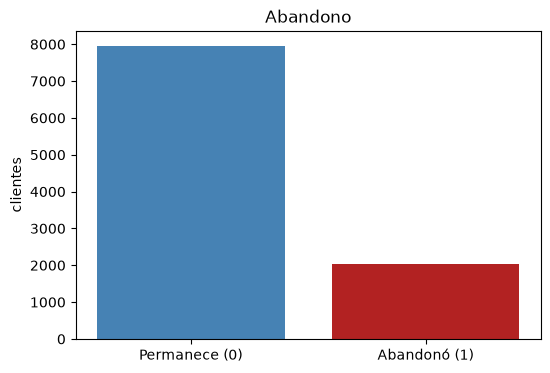

In [11]:
conteo = datos["abandono"].value_counts().sort_index()
plt.bar(["Permanece (0)", "Abandonó (1)"], conteo.values, color=["steelblue", "firebrick"])
plt.ylabel("clientes")
plt.title("Abandono")
plt.show()

In [12]:
datos[["edad", "puntaje_crediticio", "saldo", "salario_estimado"]].describe()

,edad,puntaje_crediticio,saldo,salario_estimado
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.921800,650.528800,76485.889288,100090.239881
std,10.487806,96.653299,62397.405202,57510.492818
min,18.000000,350.000000,0.000000,11.580000
25%,32.000000,584.000000,0.000000,51002.110000
50%,37.000000,652.000000,97198.540000,100193.915000
75%,44.000000,718.000000,127644.240000,149388.247500
max,92.000000,850.000000,250898.090000,199992.480000


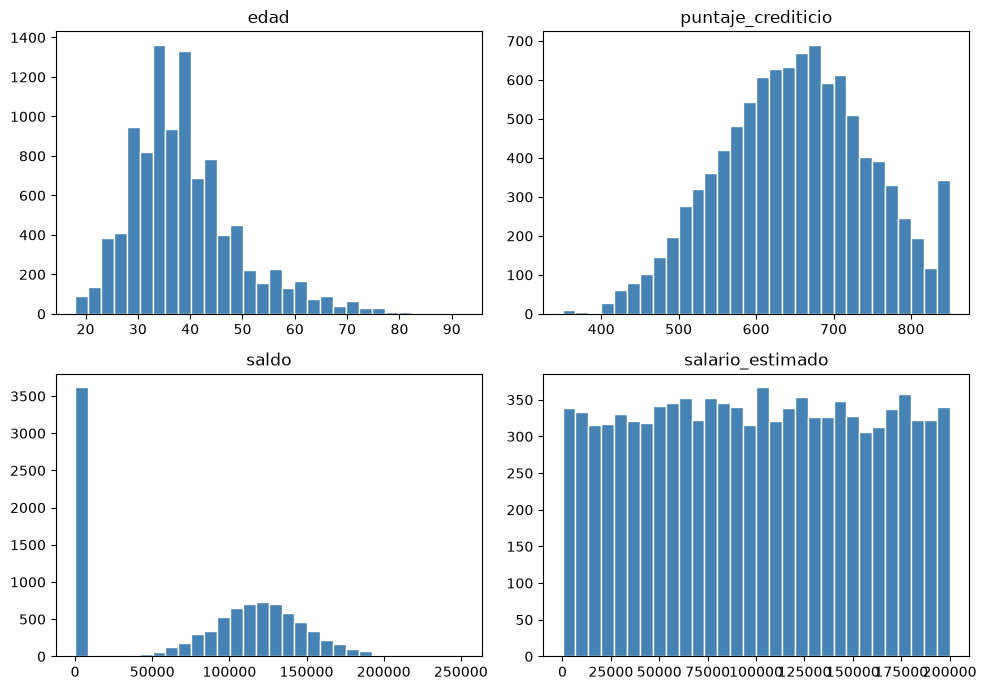

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
columnas = ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]
for ax, col in zip(axes.flat, columnas):
    ax.hist(datos[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [14]:
datos["pais"].value_counts()

pais
Francia     5014
Alemania    2509
España      2477
Name: count, dtype: int64

In [15]:
datos["sexo"].value_counts()

sexo
Hombre    5457
Mujer     4543
Name: count, dtype: int64

In [16]:
datos["numero_productos"].value_counts().sort_index()

numero_productos
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [17]:
datos["miembro_activo"].value_counts()

miembro_activo
1    5151
0    4849
Name: count, dtype: int64

### Respuesta Punto 2
5. El 20,37% de los clientes abandonó (2.037 de 10.000) y el 79,63% se quedó. Por eso, un modelo que diga siempre "permanece", sin analizar nada, acertaría el 79,63% de las veces, y eso parece bueno. Pero no sirve para nada, porque no detectaría ni un solo cliente de los que se van, que son justo los que le interesan al banco. Por eso la exactitud sola engaña cuando una de las dos clases es mucho más pequeña que la otra.


# Punto 3

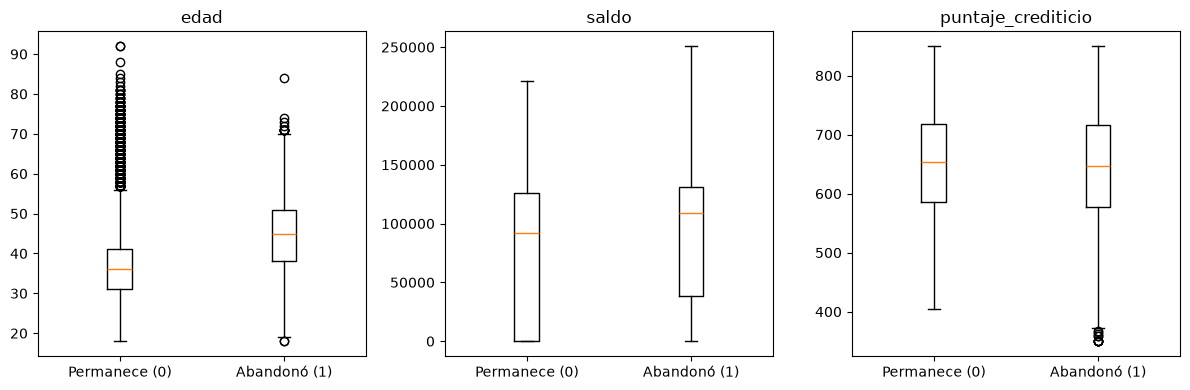

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [datos.loc[datos["abandono"] == g, col] for g in [0, 1]]
    ax.boxplot(grupos)
    ax.set_xticklabels(["Permanece (0)", "Abandonó (1)"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [19]:
datos.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].median()

,edad,saldo,puntaje_crediticio
abandono,,,
0,36.0,92072.68,653.0
1,45.0,109349.29,646.0


In [25]:
tab_activo = pd.crosstab(datos["miembro_activo"], datos["abandono"])
print(tab_activo)
print(pd.crosstab(datos["miembro_activo"], datos["abandono"], normalize="index").round(3))
chi2, p, dof, esp = chi2_contingency(tab_activo)
print("chi2 =", round(chi2, 1), " p =", round(p, 4))

abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735
abandono            0      1
miembro_activo              
0               0.731  0.269
1               0.857  0.143
chi2 = 243.0  p = 0.0


In [24]:
tab_productos = pd.crosstab(datos["numero_productos"], datos["abandono"])
print(tab_productos)
print(pd.crosstab(datos["numero_productos"], datos["abandono"], normalize="index").round(3))
chi2, p, dof, esp = chi2_contingency(tab_productos)
print("chi2 =", round(chi2, 1), " p =", round(p, 4))

abandono             0     1
numero_productos            
1                 3675  1409
2                 4242   348
3                   46   220
4                    0    60
abandono              0      1
numero_productos              
1                 0.723  0.277
2                 0.924  0.076
3                 0.173  0.827
4                 0.000  1.000
chi2 = 1503.6  p = 0.0


In [23]:
tab_pais = pd.crosstab(datos["pais"], datos["abandono"])
print(tab_pais)
print(pd.crosstab(datos["pais"], datos["abandono"], normalize="index").round(3))
chi2, p, dof, esp = chi2_contingency(tab_pais)
print("chi2 =", round(chi2, 1), " p =", round(p, 4))

abandono     0    1
pais               
Francia   4204  810
Alemania  1695  814
España    2064  413
abandono      0      1
pais                  
Francia   0.838  0.162
Alemania  0.676  0.324
España    0.833  0.167
chi2 = 301.3  p = 0.0


### Respuesta Punto 3

6. Los que abandonan son más viejos: su mediana de edad es 45 años, contra 36 de los que se quedan. En el boxplot su caja está claramente más arriba, así que a mayor edad parece haber más abandono.

7. En saldo, los que se van tienen una mediana más alta (109.349 contra 92.072), lo cual es curioso porque uno esperaría que los clientes con más plata se quedaran. En puntaje crediticio casi no hay diferencia (646 contra 653), así que no parece distinguir a los dos grupos.

8. Sí. De los inactivos se va el 26,9% y de los activos solo el 14,3%, casi la mitad. El ji-cuadrado da p ≈ 0, así que la diferencia es significativa.

9. No siempre. Con 1 producto se va el 27,7% y con 2 baja a 7,6%, pero con 3 sube a 82,7% y con 4 se van todos. O sea, 2 productos es lo ideal y 3 o 4 son mala señal, aunque esos clientes son pocos (266 y 60). El ji-cuadrado da p ≈ 0.

10. Número de productos. Es la variable con las diferencias más grandes en la tasa de abandono (de 7,6% a 100%) y la que tiene el ji-cuadrado más alto (1.503,6, contra 301,3 de país y 243 de miembro activo). También se destacan la edad (45 vs. 36 años) y Alemania, donde se va el 32,4%, casi el doble que en Francia y España.